In [1]:
import numpy as np
import matplotlib.pyplot as plt

# pytorch stuff
import torch
import torch.nn as nn
from torch.nn import functional as F

from transformers import AutoModelForCausalLM,GPT2Tokenizer

# for text printing
import textwrap

In [2]:
# use the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load pretrained GPT-2 model and tokenizer
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2-medium').to(device)
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token # set pad token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

# Create and test loss functions

In [3]:
class myLoss_x(nn.Module):
  def __init__(self):
    super().__init__()

    # mask: 1 if token contains a target, 0 otherwise
    self.mask = torch.zeros(tokenizer.vocab_size, device=device)
    for t in range(tokenizer.vocab_size):
      thistoken = tokenizer.decode([t])
      if 'x' in thistoken:
        self.mask[t] = 1

    # normalize to pdist
    self.mask = self.mask/torch.sum(self.mask)

  def forward(self, log_probs):
    # assumes log-softmax-prob input!
    return F.kl_div(log_probs, self.mask, reduction='batchmean')

In [4]:
# create a loss function instance
loss_function = myLoss_x().to(device)

In [7]:
batch_size = 4
seq_len = 64

# generate data and move data to GPU
X = torch.randint(0,tokenizer.vocab_size,(batch_size,seq_len)).to(device)

# forward pass (disable gradient-associated calculations)
with torch.no_grad():
  out = gpt2(X)

print(f'Model input has size: {X.shape}')
print(f'Model output has size: {out[0].shape}')

Model input has size: torch.Size([4, 64])
Model output has size: torch.Size([4, 64, 50257])


In [8]:
# is this a probability distribution, a log-probdist, or neither?
print(f'Sum of outputs for one token: {out[0][0,0,:].sum()}')
print(f'Sum of exp(outputs) for one token: {torch.exp(out[0][0,0,:]).sum()}')

Sum of outputs for one token: -3669008.75
Sum of exp(outputs) for one token: 3.94183563799075e-25


In [9]:
# reshape the output and transform to log-softmax
logprobs = F.log_softmax(out[0],dim=-1)
logprobs_reshape = logprobs.view(-1,tokenizer.vocab_size)

print('Shape of logprob(logits):   ',logprobs.shape)
print('Shape of reshaped logprobs: ',logprobs_reshape.shape)
print('Shape of loss function mask:',loss_function.mask.shape)

Shape of logprob(logits):    torch.Size([4, 64, 50257])
Shape of reshaped logprobs:  torch.Size([256, 50257])
Shape of loss function mask: torch.Size([50257])


In [10]:
# calculate KL losses
loss_function(logprobs_reshape)

tensor(6.3699, device='cuda:0')

# Train the model

In [11]:
# pre-fine-tuning evals
X = tokenizer.encode('Why did the chicken cross the road?',return_tensors='pt').to(device)
Y = gpt2.generate(X,do_sample=True,max_length=200)
print(textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100))


# how many generated tokens contain a target letter?
hasTarget = 0
for t in Y[0][len(X[0]):]:
  if 'x' in tokenizer.decode(t):
    hasTarget += 1

print('\n\n')
print(f'{hasTarget} of {len(Y[0][len(X[0]):])} tokens have a target.')

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Why did the chicken cross the road?  So you want to be an inventor? How on Earth would you teach
someone how to do something like that?<|endoftext|>



1 of 25 tokens have a target.


In [12]:
optimizer = torch.optim.AdamW(gpt2.parameters(),lr=1e-4,weight_decay=.01)

In [13]:
num_epochs = 300

# initialize losses
total_loss = np.zeros(num_epochs)


for epoch in range(num_epochs):

  # generate data and move data to GPU
  X = torch.randint(0,tokenizer.vocab_size,(batch_size,seq_len)).to(device)

  # forward pass
  optimizer.zero_grad()
  logits = gpt2(X)[0]

  # calculate the losses
  logits_reshape = logits.view(-1,tokenizer.vocab_size)
  logprobs_reshape = F.log_softmax(logits_reshape,dim=-1)
  loss = loss_function(logprobs_reshape)

  # backprop
  loss.backward()
  optimizer.step()

  # get the loss
  total_loss[epoch] = loss.item()

  # update our progress :)
  if epoch%37==0:
    print(f'Finished epoch {epoch:4} with loss {total_loss[epoch]:.4f}')

Finished epoch    0 with loss 6.1193
Finished epoch   37 with loss 0.0409
Finished epoch   74 with loss 0.0083
Finished epoch  111 with loss 0.0046
Finished epoch  148 with loss 0.0031
Finished epoch  185 with loss 0.0024
Finished epoch  222 with loss 0.0016
Finished epoch  259 with loss 0.0013
Finished epoch  296 with loss 0.0011


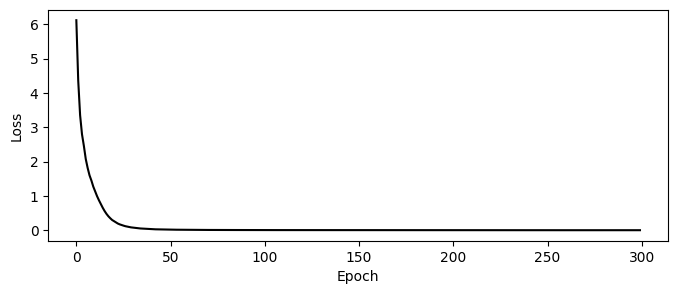

In [14]:
# plot the losses
plt.figure(figsize=(8,3))
plt.plot(total_loss,'k')
plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()

In [15]:
# post-fine-tuning evals
X = tokenizer.encode('Why did the chicken cross the road?',return_tensors='pt').to(device)
Y = gpt2.generate(X,do_sample=True,max_length=200)
print(textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100))


# how many generated tokens contain a target letter?
hasTarget = 0
for t in Y[0][len(X[0]):]:
  if 'x' in tokenizer.decode(t):
    hasTarget += 1

print('\n\n')
print(f'{hasTarget} of {len(Y[0][len(X[0]):])} tokens have a target.')

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Why did the chicken cross the road?xxxxxxxxxbexxitxxxitsexualixturexiExxxxextonAxxb fixturexpxyboxxd
Pixxixthexaxyfx xxfixesexpectedexcxpxaxbfxyxxxxxmix xxixiegexxonxiFoxgexxexpectedxmlxttxplexMixox Ph
oenixtxtxxxxxxxxmixxxxxxxxxxxxxxffxonTxExitxxxualgexxitSexualxffRexoenixyxTexxsxxPhoenixhexhexxxfxix
ExpmxxualuxePhoenixoxoenixxesSexuallextxExtraRexxesxfExcxexextonxyxySaxxsxmlxfExtraaxxitPhoenixxixus
xitextrayxgexxfSexTxyx ExtxbExcExtratxtFixed ExtexcxxFixExp
PhoenixIndexxyFixedTexxesxitDexwxxtboxesIndexxesuxexbPhoenix RoxinxExactlyrixXboxfxDexouxxtxtxbxcFox
xcxitxyTxExecutivemixinxxaTxxfxdxffExtrauxeDexPhoenixfxuxExtraExtraax
extrasAlexanderxiousxtxcxffAlexanderPhoenixtexExactly Rox Express



192 of 192 tokens have a target.
